In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

# Simple Usage

In [2]:
import sys
sys.path.append('../')
from CEmulator.Emulator import Pkhm_CEmulator
csstemu = Pkhm_CEmulator(verbose=True)

Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir_bound emulator...
Using 129 training samples.
Loading the bhmNumBin_RockstarM200m emulator...
Using 129 training samples.
Loading the BkhmNumBin_RockstarM200m emulator...
Using 129 training samples.


In [33]:
%%time
ic       = 0
zlists   = 1/np.loadtxt("/home/chenzhao/csst/simulation/zs_list12.txt") - 1
cosmoall = np.load("/home/chenzhao/csst/simulation/data/cosmologies_8d_train_n129_Sobol.npy")
Omegacb  = cosmoall[ic,1] - cosmoall[ic,7]/93.14/cosmoall[ic,2]/cosmoall[ic,2]*1e4
csstemu.set_cosmos(Omegab=cosmoall[ic,0], Omegac=cosmoall[ic,1]-cosmoall[ic,0], H0=cosmoall[ic,2],
                    ns=cosmoall[ic,3], As=cosmoall[ic,4]*1e-9, w=cosmoall[ic,5], 
                    wa=cosmoall[ic,6], mnu=cosmoall[ic,7])
klist = np.load("../CEmulator/data/karr_nb_Nmesh3072.npy")[:1644]
zlist = np.array([0.])
lgdens = [-3.5, -3.0, -2.5]
legstrs = [r"$\bar{n}=10^{%.1f}$"%(iden) for iden in lgdens]
pkhm = csstemu.get_pkhm_lgnbar_threshold(z=zlist, k=klist, lgden=lgdens)
print(pkhm.shape)

-3.5
-3.0
-2.5
(3, 1, 1644)
CPU times: user 390 ms, sys: 8.04 ms, total: 398 ms
Wall time: 395 ms


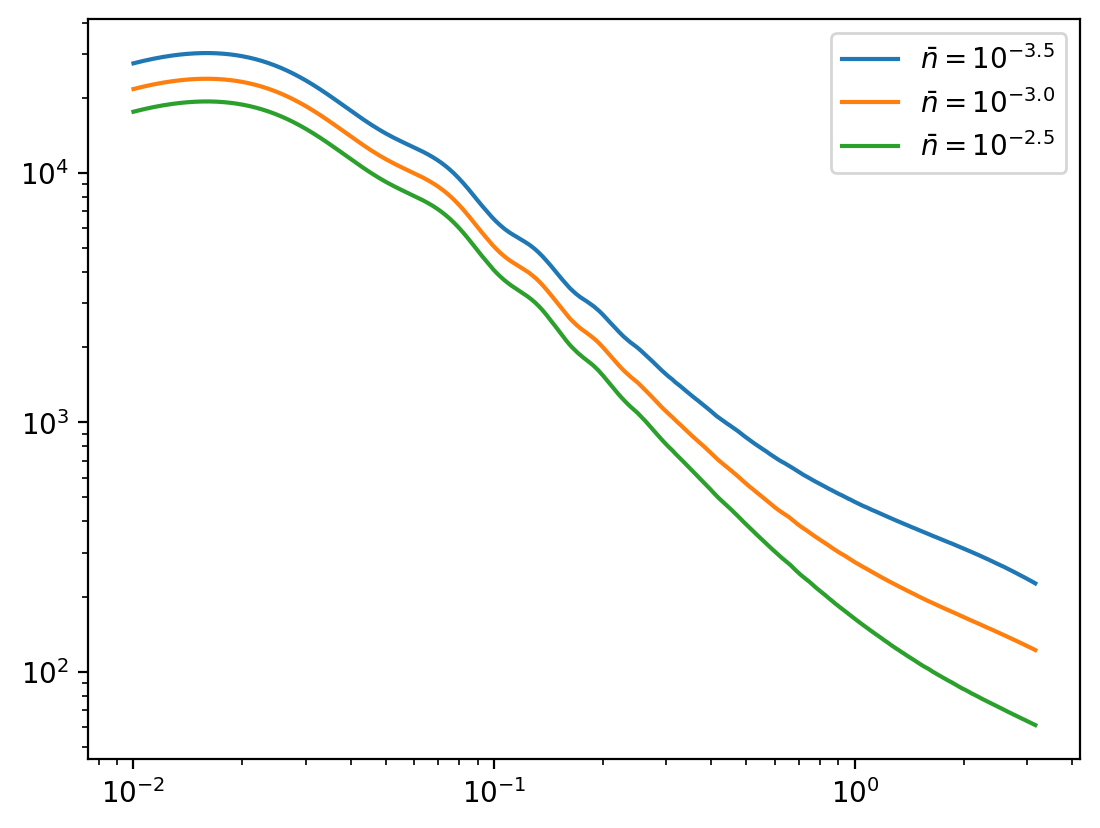

In [26]:
for ii in range(len(lgdens)):
    plt.plot(klist, pkhm[ii,0], label=legstrs[ii])
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [27]:
%%time
mths    = np.array([2e12,1e13,5e13])
legstrs = [r"$M \geq 10^{%.2f}$"%(np.log10(im)) for im in mths]
pkhm = csstemu.get_pkhm_mass_threshold(z=zlist, k=klist, M=mths)
print(pkhm.shape)

-2.7015721811123967
-3.4799514751922223
-4.473668398177748
(3, 1, 1000)
CPU times: user 1.4 s, sys: 11.1 ms, total: 1.41 s
Wall time: 1.41 s


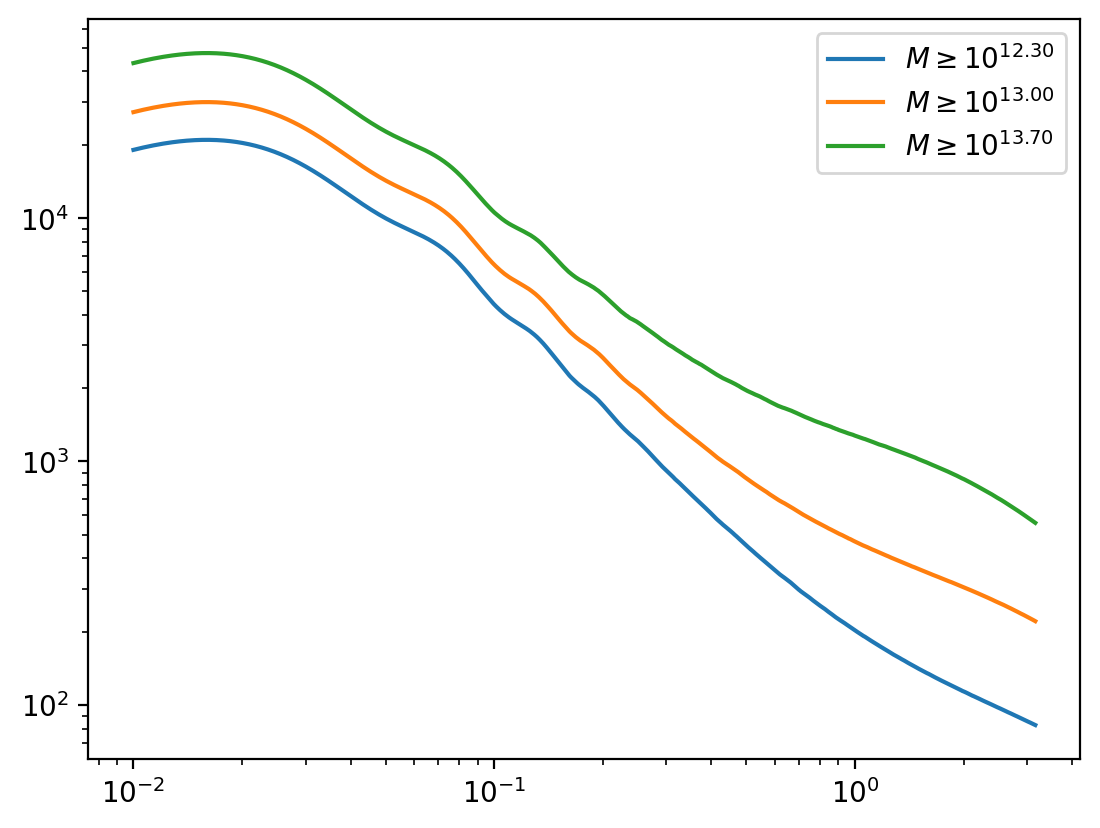

In [30]:
for ii in range(3):
    plt.plot(klist, pkhm[ii,0], label=legstrs[ii])
plt.xscale('log')
plt.yscale('log')
plt.legend()